
<div dir=ltr align=center>

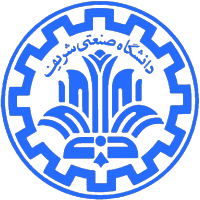

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Virtual Autoencoder<br>
<font color=696880 size=4>
Prepared by Group 38

____

In [2]:
# Group Members
Names = [
    'Farid Mahmoudzadeh',
    'Parsa Malekian',
    'Fatemeh Shafiee',
]
Studen_IDs = [
    '401106493',
    '402171075',
    '402110877',
]



# Setup

## Imports

In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Reproducibility

In [4]:
# Set global seed for reproducibility
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Provide Data + EDA

## Data Provision

In [5]:
# ==============================
# Download / Load Dataset
# ==============================

data_dir = "./data"

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))   # Normalize to [-1, 1]
])

# Load full training set
full_train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)
# Train / Validation Split
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Load test set
test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [6]:
# Dataset Samples
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# Image Shape
sample_image, sample_label = train_dataset[0]
print("Single image shape:", sample_image.shape)

Train samples: 54000
Validation samples: 6000
Test samples: 10000
Single image shape: torch.Size([1, 28, 28])


In [7]:
# ==============================
# DataLoaders
# ==============================

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 422
Validation batches: 47
Test batches: 79


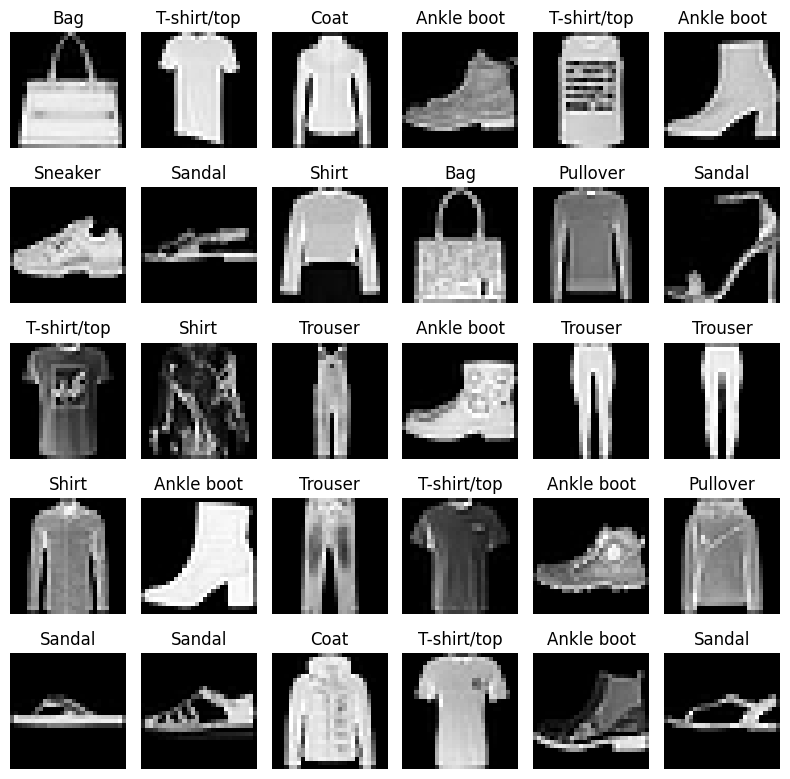

In [8]:
# ==============================
# Sanity Check (30 pictures)
# ==============================

class_names = full_train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(5, 6, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.5 + 0.5  # Unnormalize for display
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## EDA

T-shirt/top: 5342
Trouser: 5389
Pullover: 5388
Dress: 5438
Coat: 5393
Sandal: 5387
Shirt: 5400
Sneaker: 5463
Bag: 5402
Ankle boot: 5398


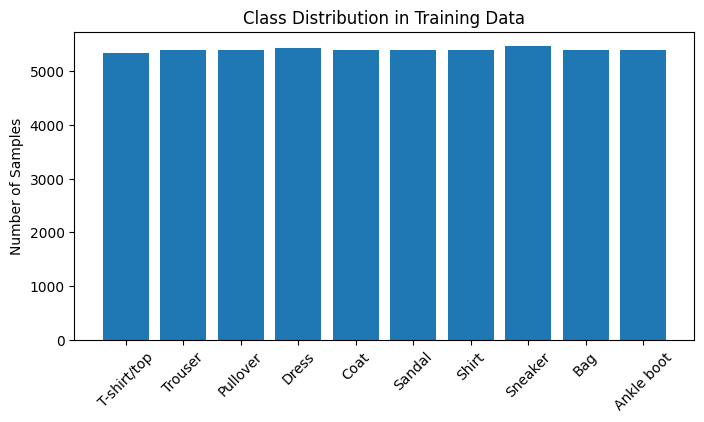

In [9]:
# ==============================
# Class Distribution
# ==============================

all_labels = []

for _, labels in train_dataset:
    all_labels.append(labels)

all_labels = np.array(all_labels)

unique, counts = np.unique(all_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{class_names[u]}: {c}")

plt.figure(figsize=(8,4))
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Samples")
plt.show()

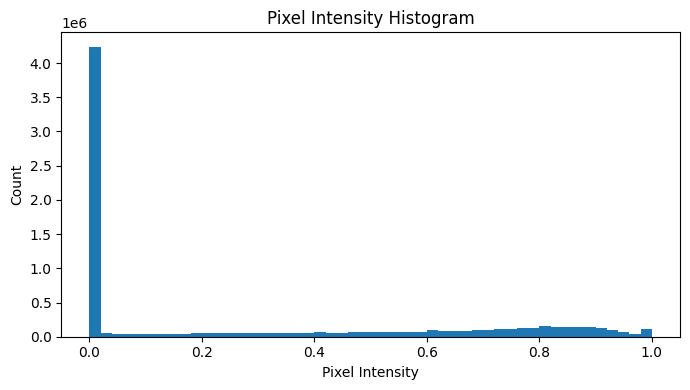

In [10]:
# ==============================
# Pixel Intensity Histogram
# ==============================

def sample_pixels(loader, max_batches=80):
    pixels = []
    used = 0
    for img, _ in loader:
        # flatten and unnormalize for intensity display
        pixels.append((img.view(-1)*0.5+0.5).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(pixels, axis=0)

pixels = sample_pixels(train_loader)
plt.figure(figsize=(7,4))
plt.hist(pixels, bins=50)
plt.title('Pixel Intensity Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

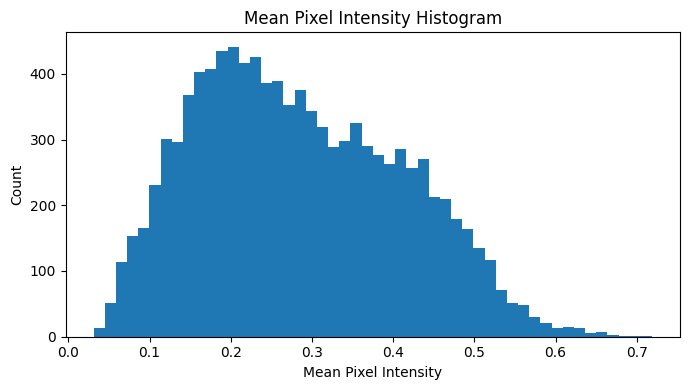

In [11]:
# ==============================
# Mean Pixel Intensity per Image
# ==============================

def sample_means(loader, max_batches=80):
    means = []
    used = 0
    for img, _ in loader:
        # Unnormalize for intensity display
        means.append((img.view(img.size(0), -1)*0.5+0.5).mean(dim=1).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(means, axis=0)

means = sample_means(train_loader)
plt.figure(figsize=(7,4))
plt.hist(means, bins=50)
plt.title('Mean Pixel Intensity Histogram')
plt.xlabel('Mean Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Phase 2 — VAE Implementation and Output Quality

### (A) Hyperparameters

In [12]:
LATENT_DIM = 16
LR = 1e-3
EPOCHS = 20
BETA = 1.0           # base model: KL weight = 1 (as requested)

### (B) VAE Model (from scratch)


Our inputs are normalized to [-1, 1], so the decoder output uses Tanh and reconstruction loss uses MSE.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: (B,1,28,28) -> (B,128,7,7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7 -> 7
            nn.ReLU(True),
        )
        self.enc_flat_dim = 128 * 7 * 7

        # Latent parameters
        self.fc_mu = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, latent_dim)

        # Decoder: z -> (B,1,28,28)
        self.fc_dec = nn.Linear(latent_dim, self.enc_flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 7 -> 14
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # output in [-1, 1]
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, 7, 7)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

### (C) Loss Function (Reconstruction + Regularization)
We choose MSE as reconstruction loss (fixed).

KL regularization is computed for $q(z|x)=\mathcal{N}(\mu,\sigma^2)$ vs $p(z)=\mathcal{N}(0, I)$.

In [14]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE), averaged per batch
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    # KL divergence, averaged per batch
    kl = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)

    total = recon + beta * kl
    return total, recon, kl

### (D) Train / Validation / Test Loops

This will let you report test reconstruction, test regularization (KL), and test total exactly as requested.

In [15]:
def run_epoch(model, loader, optimizer=None, beta=1.0, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
    n_batches = 0

    for x, _ in loader:
        x = x.to(device)

        if is_train:
            optimizer.zero_grad()

        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "recon": total_recon / n_batches,
        "kl": total_kl / n_batches,
    }

### (E) Training the Base VAE (beta=1)

In [16]:
model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(model, train_loader, optimizer=optimizer, beta=BETA, device=device)
    val_m   = run_epoch(model, val_loader, optimizer=None, beta=BETA, device=device)

    history["train"].append(train_m)
    history["val"].append(val_m)

    print(
        f"Epoch {epoch:02d} | "
        f"train: loss={train_m['loss']:.4f}, recon={train_m['recon']:.4f}, kl={train_m['kl']:.4f} | "
        f"val: loss={val_m['loss']:.4f}, recon={val_m['recon']:.4f}, kl={val_m['kl']:.4f}"
    )

Epoch 01 | train: loss=112.4599, recon=95.1413, kl=17.3185 | val: loss=73.6182, recon=54.5972, kl=19.0209
Epoch 02 | train: loss=69.4716, recon=50.3749, kl=19.0967 | val: loss=67.3920, recon=47.7582, kl=19.6338
Epoch 03 | train: loss=65.3282, recon=45.8798, kl=19.4484 | val: loss=64.5332, recon=44.5917, kl=19.9414
Epoch 04 | train: loss=63.4493, recon=43.8663, kl=19.5829 | val: loss=63.4556, recon=44.7197, kl=18.7359
Epoch 05 | train: loss=62.1096, recon=42.5071, kl=19.6025 | val: loss=62.3729, recon=42.8478, kl=19.5251
Epoch 06 | train: loss=61.1485, recon=41.4746, kl=19.6739 | val: loss=61.5843, recon=42.6752, kl=18.9091
Epoch 07 | train: loss=60.4448, recon=40.7667, kl=19.6781 | val: loss=60.8347, recon=40.6729, kl=20.1618
Epoch 08 | train: loss=59.8816, recon=40.1838, kl=19.6978 | val: loss=60.4538, recon=40.7481, kl=19.7057
Epoch 09 | train: loss=59.4151, recon=39.6921, kl=19.7230 | val: loss=60.3166, recon=41.4549, kl=18.8616
Epoch 10 | train: loss=59.0198, recon=39.2975, kl=19.7

Loss curves:

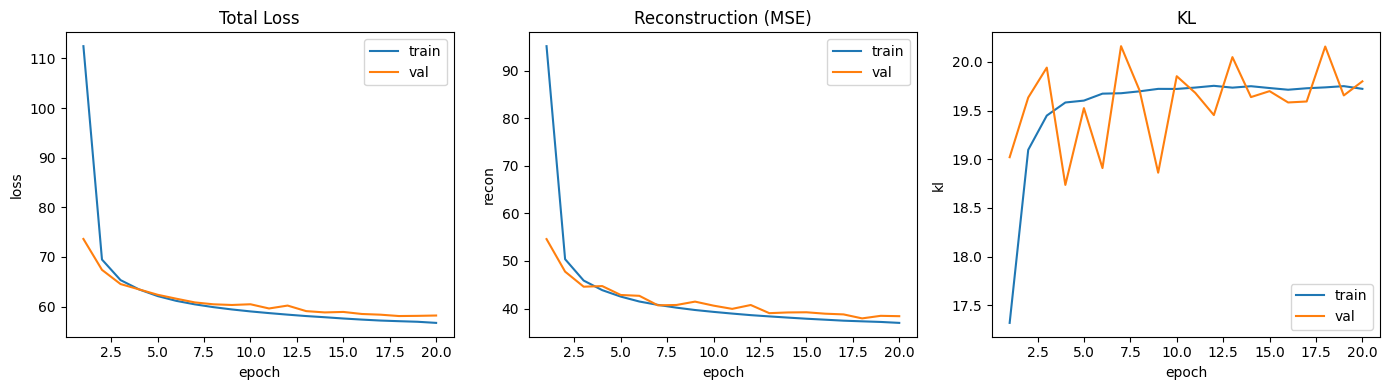

In [17]:
def plot_history(history):
    epochs = np.arange(1, len(history["train"]) + 1)

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, [h["loss"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["loss"] for h in history["val"]], label="val")
    plt.title("Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, [h["recon"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["recon"] for h in history["val"]], label="val")
    plt.title("Reconstruction (MSE)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, [h["kl"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["kl"] for h in history["val"]], label="val")
    plt.title("KL")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### (F) Test Set Report (Reconstruction / Regularization / Total)

This is exactly what the project asks you to report on the test set.

In [18]:
test_m = run_epoch(model, test_loader, optimizer=None, beta=BETA, device=device)

print("\nTEST SET METRICS (base VAE, beta=1):")
print(f"reconstruction (MSE): {test_m['recon']:.6f}")
print(f"regularization (KL):  {test_m['kl']:.6f}")
print(f"total:               {test_m['loss']:.6f}")


TEST SET METRICS (base VAE, beta=1):
reconstruction (MSE): 38.553712
regularization (KL):  19.690304
total:               58.244016


### (G) Reconstruction Visualization (≥ 20 input/output pairs)

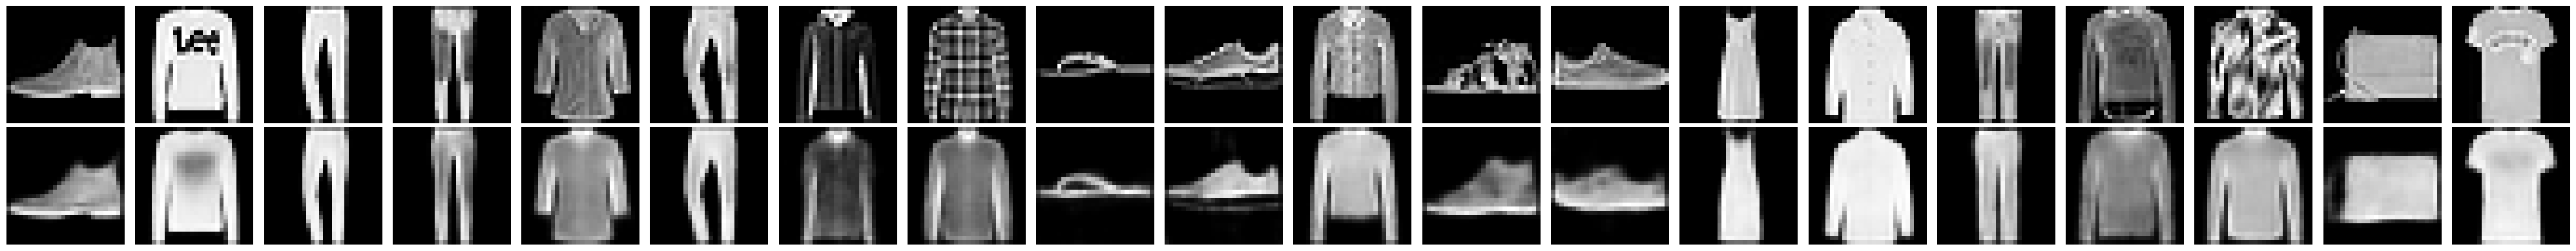

In [19]:
def show_reconstructions(model, loader, n=20, device="cuda"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    with torch.no_grad():
        x_hat, _, _ = model(x)

    # Unnormalize for display: [-1,1] -> [0,1]
    x_vis = (x.cpu() * 0.5) + 0.5
    xhat_vis = (x_hat.cpu() * 0.5) + 0.5

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(x_vis[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(xhat_vis[i, 0], cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Input", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=20, device=device)

### (H) Sampling Visualization (≥ 50 generated images)

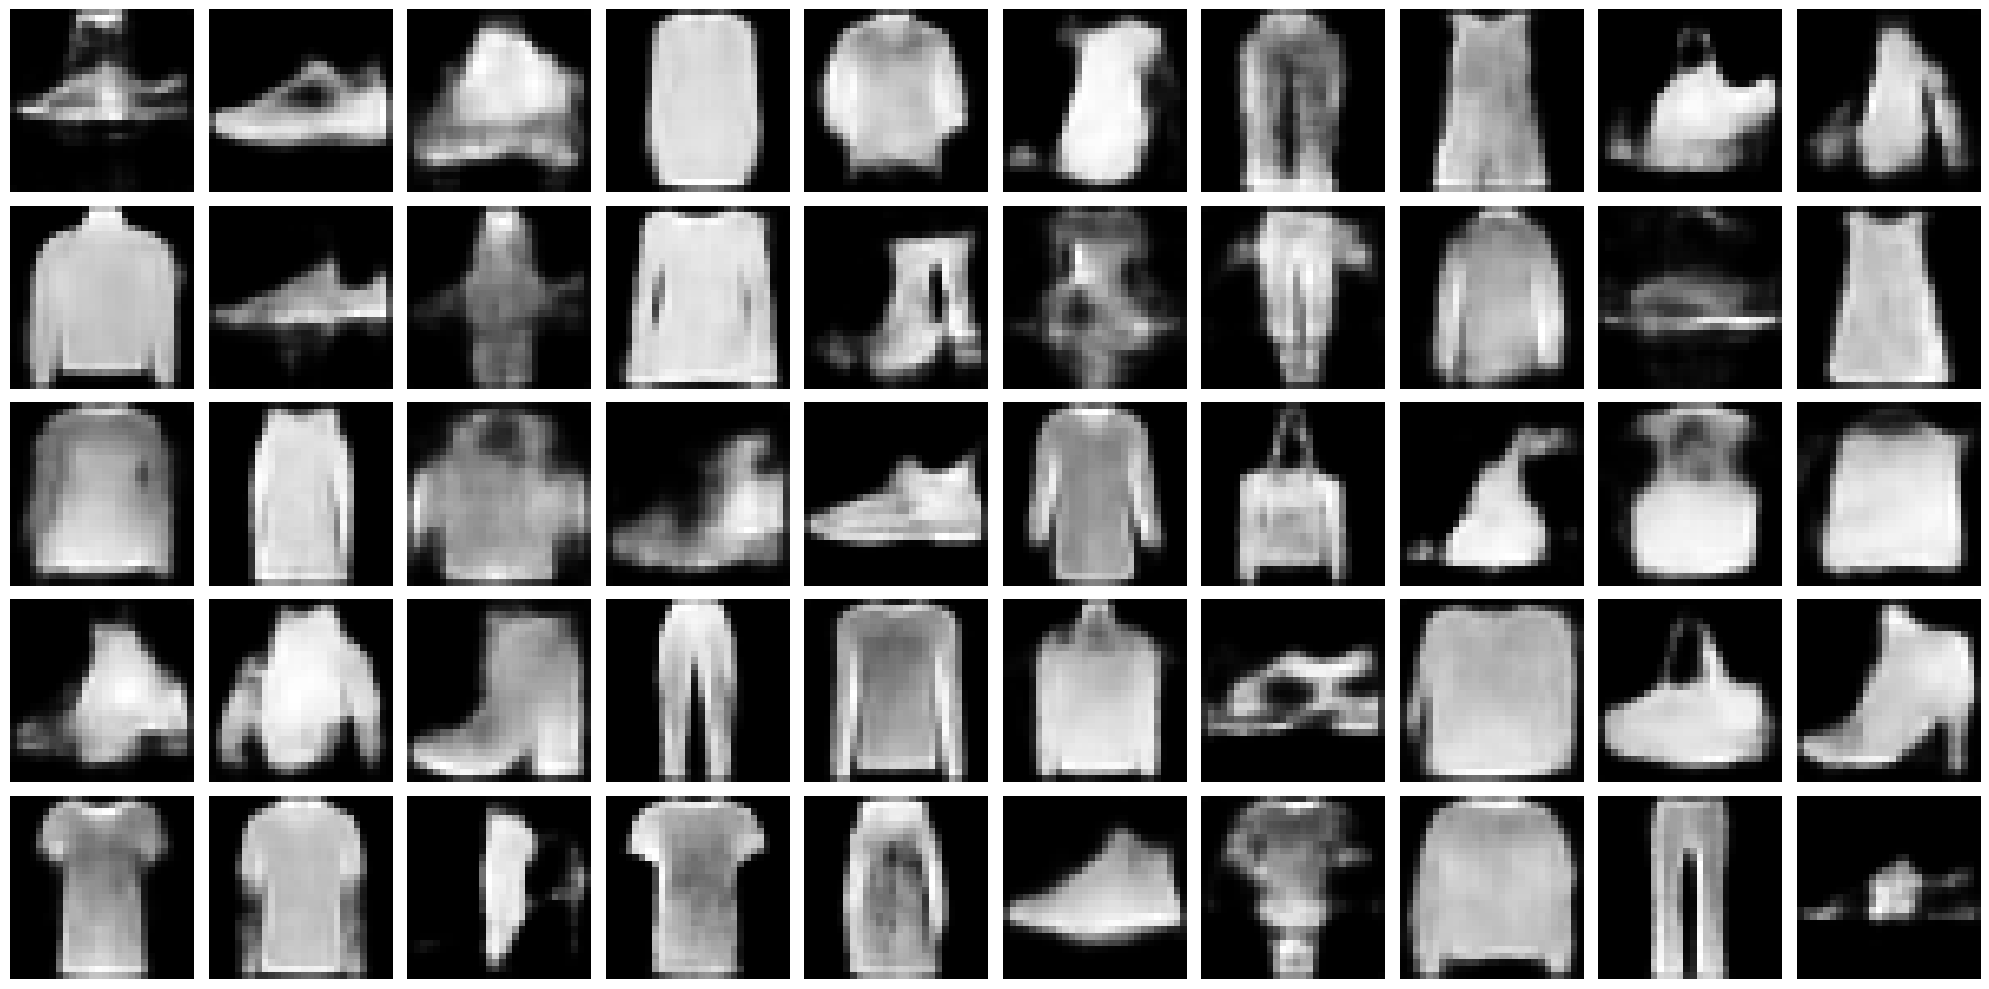

In [20]:
def sample_from_prior(model, n=50, device="cuda"):
    model.eval()
    z = torch.randn(n, model.latent_dim).to(device)

    with torch.no_grad():
        x_gen = model.decode(z)

    x_vis = (x_gen.cpu() * 0.5) + 0.5

    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(x_vis[i, 0], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

sample_from_prior(model, n=50, device=device)

## Phase 2 - improvement

### 0) Keep baseline model safely

In [22]:
import copy

baseline_model = copy.deepcopy(model).to(device)
baseline_latent_dim = baseline_model.latent_dim
baseline_beta = BETA  # should be 1.0

# Evaluate baseline on test (again, to store values for the comparison table)
baseline_test = run_epoch(baseline_model, test_loader, optimizer=None, beta=baseline_beta, device=device)

print("\nBASELINE TEST METRICS:")
print(f"reconstruction (MSE): {baseline_test['recon']:.6f}")
print(f"regularization (KL):  {baseline_test['kl']:.6f}")
print(f"total:               {baseline_test['loss']:.6f}")


BASELINE TEST METRICS:
reconstruction (MSE): 38.673536
regularization (KL):  19.690304
total:               58.363840


 -----------------------------
### 1) Improved model setup
Change: latent dimension
 -----------------------------

In [24]:
IMPROVED_LATENT_DIM = 64
IMPROVED_EPOCHS = EPOCHS     # keep same epochs for fair comparison
IMPROVED_LR = LR
IMPROVED_BETA = 1.0          # keep beta=1 like baseline (only change latent dim)

improved_model = ConvVAE(latent_dim=IMPROVED_LATENT_DIM).to(device)
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=IMPROVED_LR)

improved_history = {"train": [], "val": []}

print(f"\nTraining IMPROVED model: latent_dim={IMPROVED_LATENT_DIM}, beta={IMPROVED_BETA}")
for epoch in range(1, IMPROVED_EPOCHS + 1):
    train_m = run_epoch(improved_model, train_loader, optimizer=improved_optimizer,
                        beta=IMPROVED_BETA, device=device)
    val_m   = run_epoch(improved_model, val_loader, optimizer=None,
                        beta=IMPROVED_BETA, device=device)

    improved_history["train"].append(train_m)
    improved_history["val"].append(val_m)

    print(
        f"Epoch {epoch:02d} | "
        f"train: loss={train_m['loss']:.4f}, recon={train_m['recon']:.4f}, kl={train_m['kl']:.4f} | "
        f"val: loss={val_m['loss']:.4f}, recon={val_m['recon']:.4f}, kl={val_m['kl']:.4f}"
    )


Training IMPROVED model: latent_dim=64, beta=1.0
Epoch 01 | train: loss=123.5478, recon=102.7920, kl=20.7557 | val: loss=79.5478, recon=58.6163, kl=20.9314
Epoch 02 | train: loss=73.5891, recon=52.5084, kl=21.0807 | val: loss=70.6034, recon=49.7776, kl=20.8258
Epoch 03 | train: loss=68.3318, recon=47.2574, kl=21.0744 | val: loss=67.4038, recon=47.0039, kl=20.3999
Epoch 04 | train: loss=65.8854, recon=44.8549, kl=21.0305 | val: loss=65.3582, recon=44.0947, kl=21.2635
Epoch 05 | train: loss=64.2931, recon=43.2527, kl=21.0404 | val: loss=64.4059, recon=43.7744, kl=20.6315
Epoch 06 | train: loss=63.1920, recon=42.2345, kl=20.9575 | val: loss=63.2057, recon=41.7842, kl=21.4215
Epoch 07 | train: loss=62.2342, recon=41.3348, kl=20.8993 | val: loss=62.8089, recon=42.5577, kl=20.2512
Epoch 08 | train: loss=61.6021, recon=40.7424, kl=20.8597 | val: loss=62.4265, recon=41.3566, kl=21.0699
Epoch 09 | train: loss=61.0709, recon=40.2484, kl=20.8225 | val: loss=61.5972, recon=40.1183, kl=21.4789
Epo


 -----------------------------
### 2) Evaluate improved on test
 -----------------------------

In [25]:
improved_test = run_epoch(improved_model, test_loader, optimizer=None, beta=IMPROVED_BETA, device=device)

print("\nIMPROVED TEST METRICS:")
print(f"reconstruction (MSE): {improved_test['recon']:.6f}")
print(f"regularization (KL):  {improved_test['kl']:.6f}")
print(f"total:               {improved_test['loss']:.6f}")


IMPROVED TEST METRICS:
reconstruction (MSE): 38.453074
regularization (KL):  20.509882
total:               58.962956


 -----------------------------
### 3) Comparison table (test set)
 ---

In [26]:
print("\nTEST SET COMPARISON TABLE")
print("-" * 90)
print(f"{'Model':<12} {'latent_dim':<10} {'beta':<6} {'recon(MSE)':<14} {'KL':<14} {'total':<14}")
print("-" * 90)
print(f"{'Baseline':<12} {baseline_latent_dim:<10d} {baseline_beta:<6.2f} "
      f"{baseline_test['recon']:<14.6f} {baseline_test['kl']:<14.6f} {baseline_test['loss']:<14.6f}")
print(f"{'Improved':<12} {IMPROVED_LATENT_DIM:<10d} {IMPROVED_BETA:<6.2f} "
      f"{improved_test['recon']:<14.6f} {improved_test['kl']:<14.6f} {improved_test['loss']:<14.6f}")
print("-" * 90)


TEST SET COMPARISON TABLE
------------------------------------------------------------------------------------------
Model        latent_dim beta   recon(MSE)     KL             total         
------------------------------------------------------------------------------------------
Baseline     16         1.00   38.673536      19.690304      58.363840     
Improved     64         1.00   38.453074      20.509882      58.962956     
------------------------------------------------------------------------------------------


 -----------------------------
### 4) Visual comparison: reconstructions (>= 20)
 -----------------------------


Reconstructions BEFORE (Baseline):


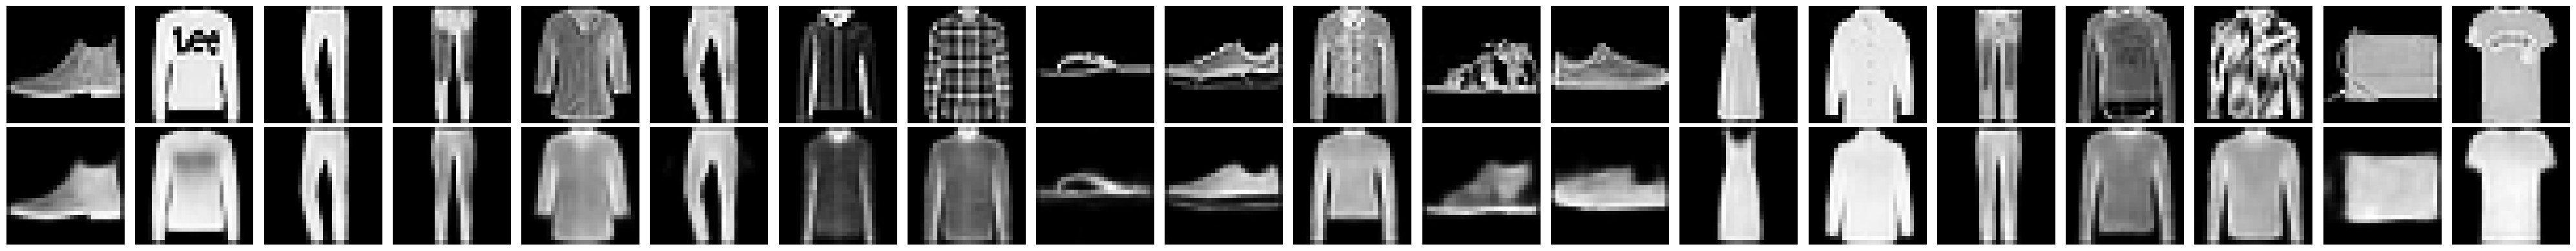


Reconstructions AFTER (Improved):


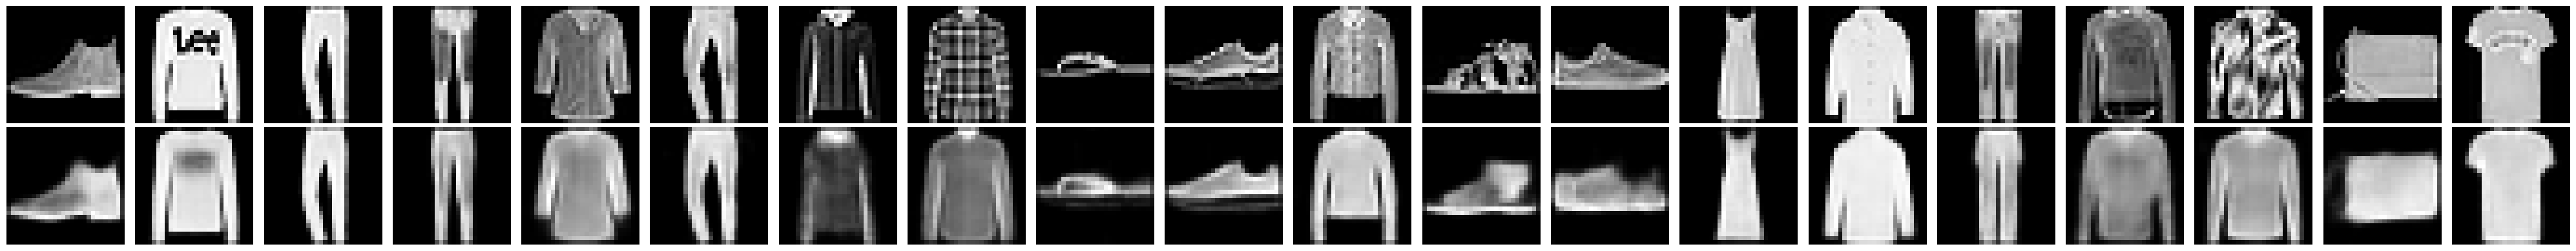

In [27]:
print("\nReconstructions BEFORE (Baseline):")
show_reconstructions(baseline_model, test_loader, n=20, device=device)

print("\nReconstructions AFTER (Improved):")
show_reconstructions(improved_model, test_loader, n=20, device=device)

 -----------------------------
### 5) Visual comparison: sampling (>= 50)
 -----------------------------


Sampling BEFORE (Baseline):


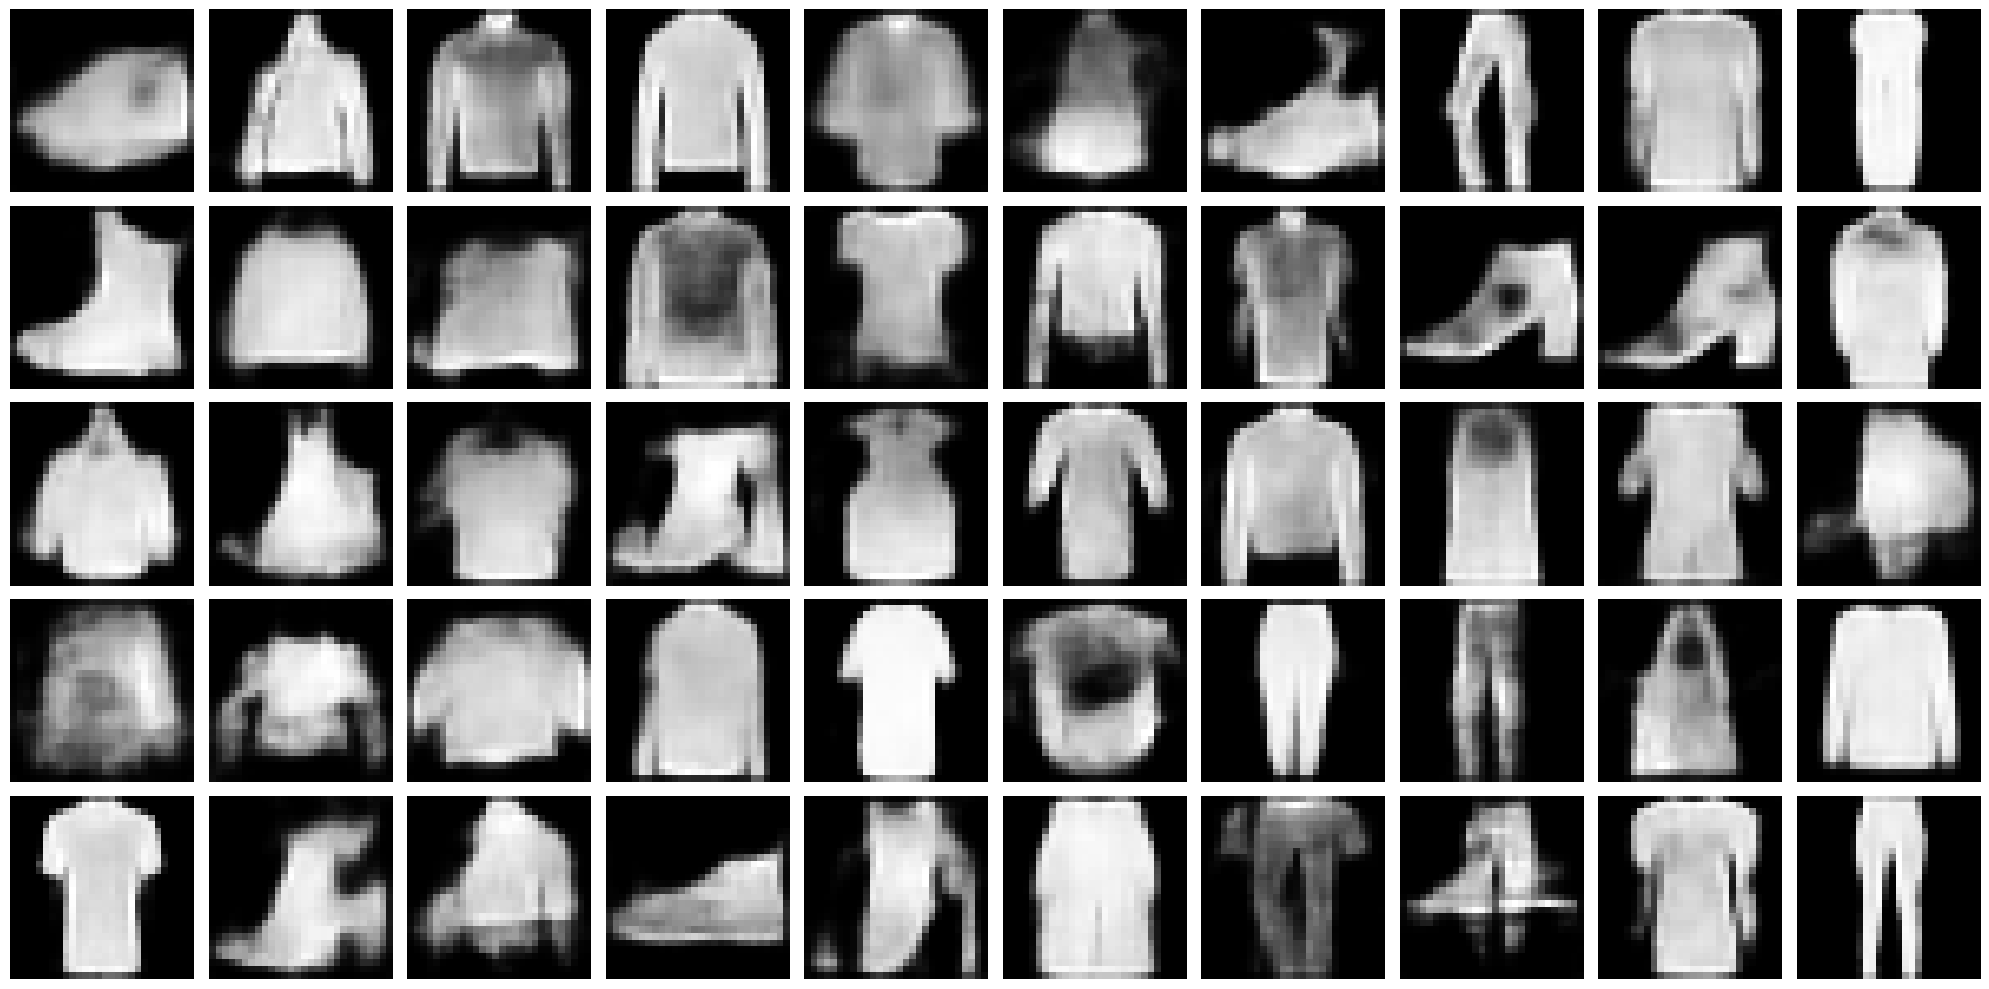


Sampling AFTER (Improved):


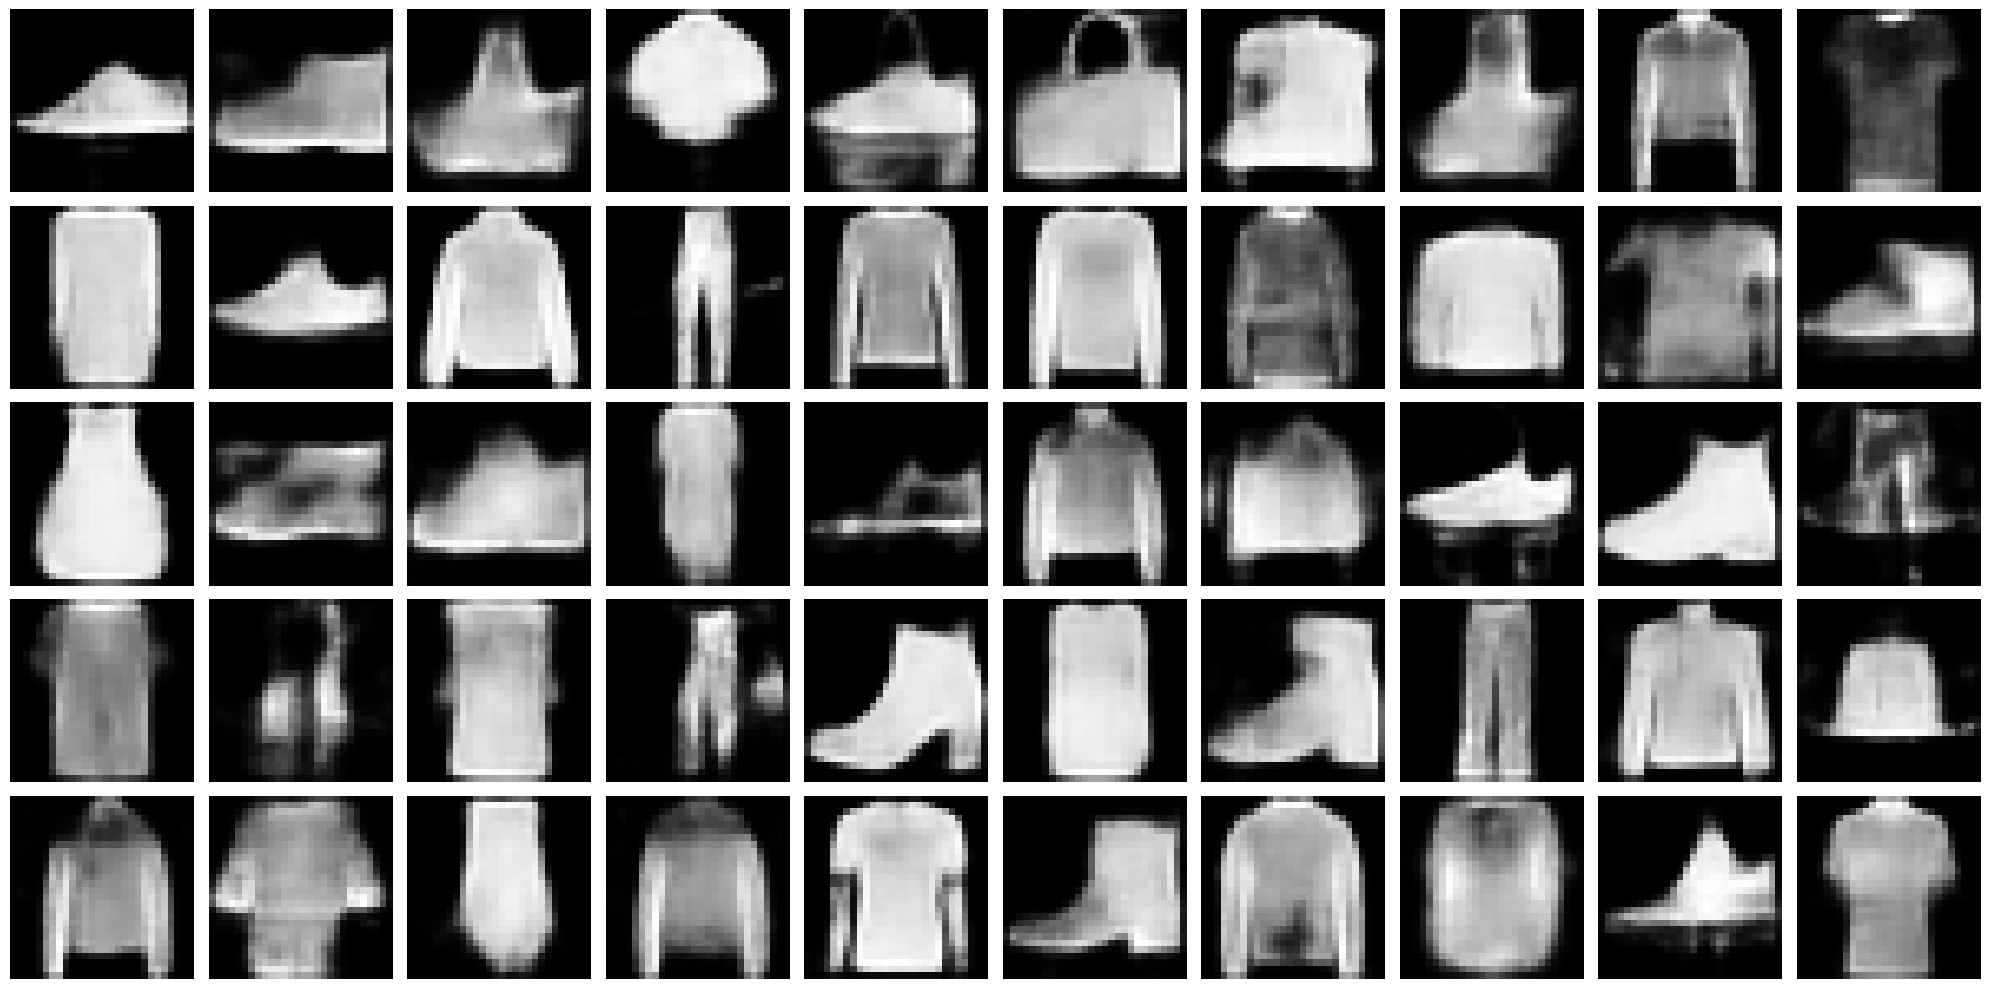

In [28]:
print("\nSampling BEFORE (Baseline):")
sample_from_prior(baseline_model, n=50, device=device)

print("\nSampling AFTER (Improved):")
sample_from_prior(improved_model, n=50, device=device)

 -----------------------------
### 6) Plot improved loss curves
 -----------------------------

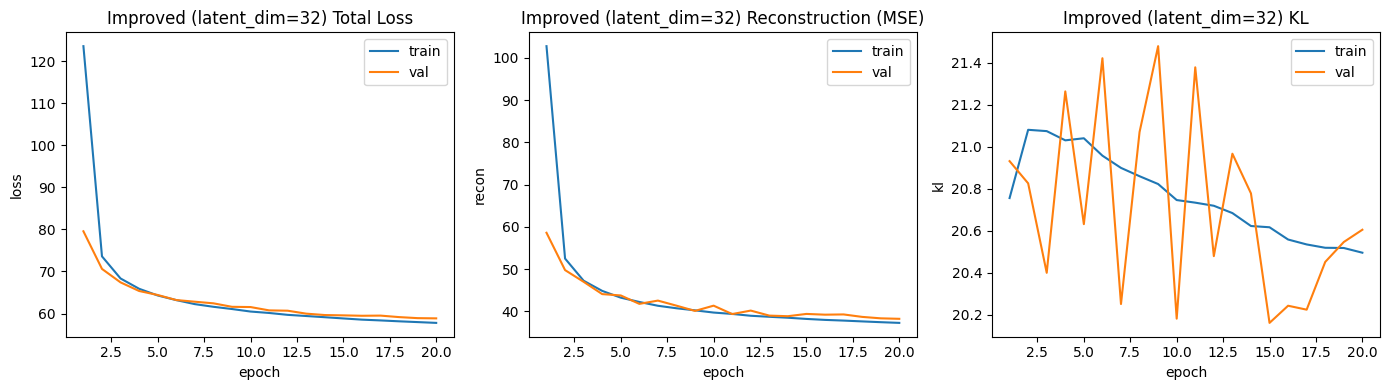

In [29]:
def plot_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train"]) + 1)

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, [h["loss"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["loss"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Total Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, [h["recon"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["recon"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} Reconstruction (MSE)")
    plt.xlabel("epoch"); plt.ylabel("recon"); plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, [h["kl"] for h in history["train"]], label="train")
    plt.plot(epochs, [h["kl"] for h in history["val"]], label="val")
    plt.title(f"{title_prefix} KL")
    plt.xlabel("epoch"); plt.ylabel("kl"); plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(improved_history, title_prefix="Improved (latent_dim=32)")